In [15]:
import os
import glob
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import umap

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize, Normalizer
from sklearn.cluster import DBSCAN, KMeans, SpectralClustering
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, BisectingKMeans

# Diccionario para almacenar los resultados y compararlos al final
resultados_globales = {}

In [16]:
def load_imdb_data(base_path, sample_size=2500):
    texts = []
    for label in ['pos', 'neg']:
        pattern = os.path.join(base_path, 'train', label, '*.txt')
        files = glob.glob(pattern)[:sample_size] # Balanceado
        for file_path in files:
            with open(file_path, encoding='utf-8') as f:
                texts.append(f.read())
    return texts

def limpiar_texto_regex(texto):
    texto = str(texto).lower()
    texto = re.sub(r'<.*?>', ' ', texto) # Quitar etiquetas HTML (<br />)
    texto = re.sub(r'(https?://\S+|www\.\S+)', ' tokenurl ', texto)
    texto = re.sub(r"\S+@\S+\.\S+", " tokencorreo ", texto)
    texto = re.sub(r"\b\d+\b", " tokennumero ", texto) # Simplificado para números
    texto = re.sub(r"[@#]", " ", texto)
    texto = re.sub(r"[^a-z0-9!$ ]", " ", texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def procesar_textos_spacy(textos):
    print("Limpiando texto con Regex y SpaCy (esto tomará un momento)...")
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
    basura_ingles = {'br', 've', 'nt', 'll', 're', 'm', 's', 'd', 't', 'movie', 'film', 'character'}
    
    textos_limpios_regex = [limpiar_texto_regex(t) for t in textos]
    textos_finales = []
    
    for doc in nlp.pipe(textos_limpios_regex, batch_size=50):
        tokens = [
            token.lemma_.lower() for token in doc 
            if token.pos_ in ['ADJ', 'ADV', 'VERB']  # Solo palabras con carga semántica/emocional
            and not token.is_space 
            and not token.is_stop
            and len(token.lemma_) > 1
            and token.lemma_.lower() not in basura_ingles
        ]
        textos_finales.append(" ".join(tokens))
    return textos_finales

# 1. CARGA
ruta_imdb = r'/home/gamesrack/Documentos/Quinto_Semestre/Codigos/Python/Machine_learning/Avance2_proyecto/IMDB_Data/aclImdb'
reviews_crudas = load_imdb_data(ruta_imdb, sample_size=2500) # 5000 en total

# 2. LIMPIEZA
reviews_limpias = procesar_textos_spacy(reviews_crudas)
print(f"Dataset listo. Total reseñas: {len(reviews_limpias)}")

Limpiando texto con Regex y SpaCy (esto tomará un momento)...
Dataset listo. Total reseñas: 5000


In [17]:
# Asegúrate de ejecutar esto ANTES de cualquier algoritmo de clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

print("Generando matriz TF-IDF...")
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english', sublinear_tf=True)

# X_tfidf se usa para K-Means y Spectral
X_tfidf = vectorizer.fit_transform(reviews_limpias)

# X_tfidf_norm se usa específicamente para DBSCAN
X_tfidf_norm = normalize(X_tfidf)

print("¡Variables X_tfidf y X_tfidf_norm creadas con éxito!")

Generando matriz TF-IDF...
¡Variables X_tfidf y X_tfidf_norm creadas con éxito!


In [18]:
print("Ejecutando DBSCAN con búsqueda de hiperparámetros...")

# 1. Reducción a 10 dimensiones y normalización L2 (vital para distancia coseno)
svd_db = TruncatedSVD(n_components=10, random_state=42)
X_db = normalize(svd_db.fit_transform(X_tfidf_norm))

n = X_db.shape[0]

# 2. Recreamos tu lógica de búsqueda de parámetros
min_samples_vals = [
    max(3, math.floor(math.log(n))),      # Clusters compactos
    max(3, math.floor(math.log(n)) * 2),  # Clusters más densos
]
eps_vals = np.linspace(0.01, 1.5, 80)     # Probamos 80 radios diferentes

best_sil_db = -1
best_eps = None
best_ms = None

# 3. Búsqueda exhaustiva (Grid Search)
for ms in min_samples_vals:
    for eps in eps_vals:
        db = DBSCAN(eps=eps, min_samples=ms, metric='cosine', n_jobs=-1)
        labels = db.fit_predict(X_db)

        # Contar clusters (ignorando el ruido -1) y porcentaje de ruido
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()

        # Filtros de sanidad: al menos 2 clusters y máximo 50% de ruido
        if n_clusters < 2 or (n_noise / n > 0.5):
            continue

        mask = labels != -1
        if mask.sum() < 100: # Mínimo de puntos para que el score sea fiable
            continue

        # Calculamos la silueta solo sobre los puntos que NO son ruido
        score = silhouette_score(X_db[mask], labels[mask], metric='cosine')

        # Guardamos el mejor resultado
        if score > best_sil_db:
            best_sil_db = score
            best_eps = eps
            best_ms = ms

# 4. Guardar resultados
if best_sil_db > -1:
    resultados_globales['DBSCAN'] = best_sil_db
    print(f"--- Resultados DBSCAN ---")
    print(f"eps óptimo:       {best_eps:.4f}")
    print(f"min_samples:      {best_ms}")
    print(f"Silhouette:       {best_sil_db:.4f}")
else:
    resultados_globales['DBSCAN'] = 0.0
    print("Sin configuración válida. Prueba ampliar eps_vals o reducir el filtro de ruido.")

Ejecutando DBSCAN con búsqueda de hiperparámetros...
--- Resultados DBSCAN ---
eps óptimo:       0.0666
min_samples:      8
Silhouette:       0.0991


In [19]:
print("Ejecutando K-Medoids con Transformers...")
model = SentenceTransformer('all-MiniLM-L6-v2')
X_embeddings = model.encode(reviews_limpias, show_progress_bar=False)

reductor = umap.UMAP(n_components=5, metric='cosine', random_state=42)
X_umap = Normalizer(copy=False).fit_transform(reductor.fit_transform(X_embeddings))

kmedoids = KMedoids(n_clusters=5, metric='cosine', method='pam', init='heuristic', random_state=42)
labels_kmed = kmedoids.fit_predict(X_umap)

sil_kmed = silhouette_score(X_umap, labels_kmed, metric='cosine')
resultados_globales['K-Medoids'] = sil_kmed
print(f"K-Medoids Silhouette: {sil_kmed:.4f}")

Ejecutando K-Medoids con Transformers...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5974.79it/s]
/home/gamesrack/Documentos/Quinto_Semestre/Codigos/Python/Machine_learning/Avance2_proyecto/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


K-Medoids Silhouette: 0.3764


In [20]:
print("Ejecutando Spectral Clustering...")
svd_spec = TruncatedSVD(n_components=50, random_state=42)
tsne_spec = TSNE(n_components=2, perplexity=30, random_state=42)

X_spec = Normalizer().fit_transform(tsne_spec.fit_transform(svd_spec.fit_transform(X_tfidf)))

spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=100)
labels_spec = spectral.fit_predict(X_spec)

sil_spec = silhouette_score(X_spec, labels_spec, metric='cosine')
resultados_globales['Spectral Clustering'] = sil_spec
print(f"Spectral Silhouette: {sil_spec:.4f}")

Ejecutando Spectral Clustering...
Spectral Silhouette: 0.5690


In [21]:
print("Ejecutando evaluación de K-Means y BisectingKMeans...")

# 1. Aplicamos tu reducción NMF sobre la matriz TF-IDF global
N_COMPONENTS = 7
nmf = NMF(n_components=N_COMPONENTS, max_iter=800, init='nndsvda', random_state=42)
X_nmf = normalize(nmf.fit_transform(X_tfidf))

print("\nTEMAS DESCUBIERTOS POR NMF:")
feature_names = vectorizer.get_feature_names_out()
for i, row in enumerate(nmf.components_):
    top_words = [feature_names[j] for j in row.argsort()[:-9:-1]]
    print(f"  Tema {i}: {', '.join(top_words)}")

# 2. Tu tabla comparativa de configuraciones
configs = [
    ("KMeans k=2", KMeans(n_clusters=2, n_init=25, max_iter=600, random_state=42)),
    ("BisectingKMeans k=5", BisectingKMeans(n_clusters=5, n_init=15, bisecting_strategy='biggest_inertia', random_state=42)),
    ("KMeans k=5", KMeans(n_clusters=5, n_init=25, max_iter=600, random_state=42)),
    ("BisectingKMeans k=8", BisectingKMeans(n_clusters=8, n_init=15, bisecting_strategy='biggest_inertia', random_state=42)),
    ("KMeans k=8", KMeans(n_clusters=8, n_init=25, max_iter=600, random_state=42)),
    ("KMeans k=10", KMeans(n_clusters=10, n_init=25, max_iter=600, random_state=42)),
]

best_sil_km = -1
best_nombre_km = ""

print("\nEvaluando configuraciones de K-Means...")
print("="*60)
print(f"{'Algoritmo':<25} {'Silhouette':>11} {'Davies-Bouldin':>15}")
print("="*60)

for nombre, modelo in configs:
    labels = modelo.fit_predict(X_nmf)
    # Calculamos métricas
    sil = silhouette_score(X_nmf, labels, metric='cosine')
    db  = davies_bouldin_score(X_nmf, labels)
    
    print(f"{nombre:<25} {sil:>11.4f} {db:>15.4f}")
    
    # Nos quedamos con el mejor para la gráfica final
    if sil > best_sil_km:
        best_sil_km = sil
        best_nombre_km = nombre

print("="*60)
print(f"Mejor configuración K-Means: {best_nombre_km} (Silhouette: {best_sil_km:.4f})")

# 3. Guardamos el MEJOR resultado en el diccionario global para la gráfica final
resultados_globales[f'K-Means Mejor ({best_nombre_km})'] = best_sil_km

Ejecutando evaluación de K-Means y BisectingKMeans...

TEMAS DESCUBIERTOS POR NMF:
  Tema 0: come, know, play, real, young, look, try, leave
  Tema 1: bad, act, terrible, awful, waste, look, horrible, stupid
  Tema 2: love, like, little, favorite, come, enjoy, know, beautiful
  Tema 3: great, wonderful, enjoy, brilliant, fantastic, excellent, especially, act
  Tema 4: good, pretty, play, excellent, act, interesting, overall, special
  Tema 5: funny, laugh, hilarious, stupid, hard, try, make, comic
  Tema 6: watch, think, enjoy, remember, feel, want, actually, maybe

Evaluando configuraciones de K-Means...
Algoritmo                  Silhouette  Davies-Bouldin
KMeans k=2                     0.2975          1.7990
BisectingKMeans k=5            0.2682          1.8169
KMeans k=5                     0.3977          1.4981
BisectingKMeans k=8            0.2497          1.6638
KMeans k=8                     0.3959          1.2177
KMeans k=10                    0.3536          1.3577
Mejor con

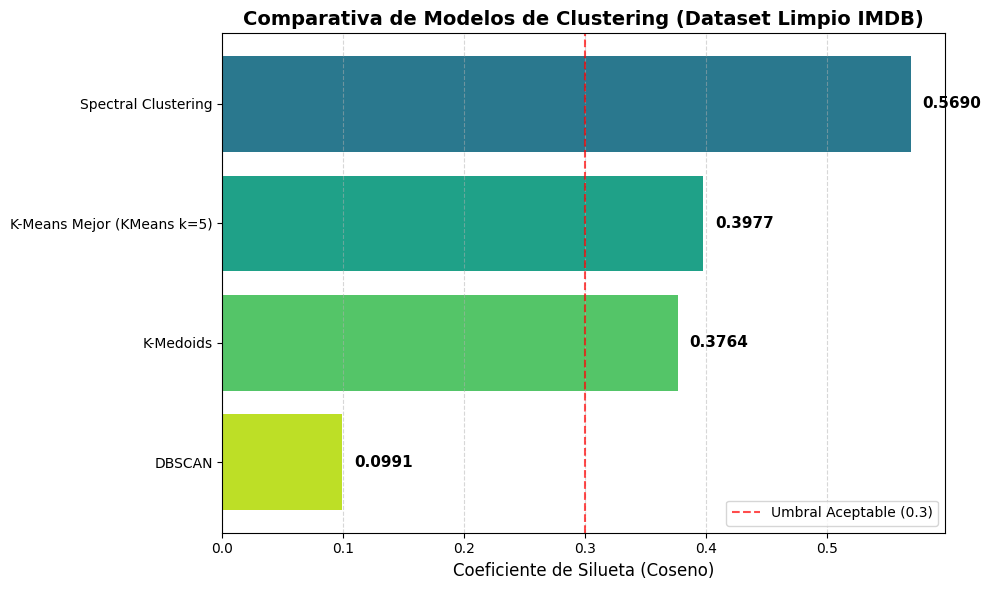

In [22]:
# Preparar datos para la gráfica
algoritmos = list(resultados_globales.keys())
scores = list(resultados_globales.values())

# Ordenar de mayor a menor para mejor visualización
sorted_indices = np.argsort(scores)[::-1]
algoritmos_ord = [algoritmos[i] for i in sorted_indices]
scores_ord = [scores[i] for i in sorted_indices]

# Crear la gráfica
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(algoritmos_ord, scores_ord, color=plt.cm.viridis(np.linspace(0.4, 0.9, len(scores_ord))))

# Personalización
ax.set_xlabel('Coeficiente de Silueta (Coseno)', fontsize=12)
ax.set_title('Comparativa de Modelos de Clustering (Dataset Limpio IMDB)', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # El mejor modelo aparecerá arriba

# Añadir el texto del valor al lado de cada barra
for bar, score in zip(bars, scores_ord):
    ax.text(score + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', 
            va='center', ha='left', fontsize=11, fontweight='bold')

# Añadir una línea de referencia para ver cuáles pasan el "mínimo aceptable"
ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, label='Umbral Aceptable (0.3)')

ax.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

# Opcional: Guardar la imagen
# plt.savefig('comparativa_clustering.png', dpi=300)